# Unit 5: Gradient Boosting Trees — Solutions

Today we'll use **CatBoost**, a gradient boosting library designed for tabular data.

**Bagging** (random forests): train many deep trees *in parallel* on bootstrapped samples, then average. Reduces variance.

**Boosting**: train many shallow trees *sequentially* — each new tree corrects the errors of the previous ensemble. Reduces bias *and* variance.

Why CatBoost:
- Handles categorical features natively (no one-hot encoding needed)
- Strong defaults, doesn't require heavy tuning
- Other popular options: XGBoost, LightGBM, `sklearn.ensemble.GradientBoostingClassifier`

In [1]:
# !pip install --upgrade catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compatibility shim: older catboost calls the deprecated DataFrame.iteritems,
# which pandas 2.0+ removed. Re-add it if missing so catboost doesn't crash.
if not hasattr(pd.DataFrame, 'iteritems'):
    pd.DataFrame.iteritems = pd.DataFrame.items

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from catboost import CatBoostClassifier, CatBoostRegressor

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# Same features

We will train a CatBoost model on the Titanic dataset.

In [2]:
titanic = sns.load_dataset('titanic')
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic = titanic.drop(columns=['who', 'embarked', 'parch', 'fare',
                                'deck', 'embark_town', 'alive', 'alone'])
titanic.head()

,survived,pclass,sex,age,sibsp,class,adult_male
0,0,3,male,22.0,1,Third,True
1,1,1,female,38.0,1,First,False
2,1,3,female,26.0,0,Third,False
3,1,1,female,35.0,1,First,False
4,0,3,male,35.0,0,Third,True


In [3]:
X = titanic.drop(columns=['survived'])
y = titanic['survived']

cat_features = ['sex', 'class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Initialize CatBoost Classifier
catboost_model = CatBoostClassifier(iterations=1000,
                                    learning_rate=0.05,
                                    depth=6,
                                    verbose=100)

# Train the model (pass cat_features so CatBoost handles them natively)
catboost_model.fit(X_train, y_train, cat_features=cat_features)

0:	learn: 0.6580557	total: 73.9ms	remaining: 1m 13s
100:	learn: 0.3623712	total: 183ms	remaining: 1.62s
200:	learn: 0.3290721	total: 288ms	remaining: 1.15s
300:	learn: 0.2948500	total: 415ms	remaining: 964ms
400:	learn: 0.2705016	total: 524ms	remaining: 782ms
500:	learn: 0.2543097	total: 635ms	remaining: 632ms
600:	learn: 0.2365760	total: 744ms	remaining: 494ms
700:	learn: 0.2223127	total: 856ms	remaining: 365ms
800:	learn: 0.2089500	total: 966ms	remaining: 240ms
900:	learn: 0.1998820	total: 1.07s	remaining: 118ms
999:	learn: 0.1909176	total: 1.19s	remaining: 0us


In [5]:
# Make predictions
y_pred_cb = catboost_model.predict(X_test)

# Evaluate CatBoost
cb_accuracy = accuracy_score(y_test, y_pred_cb)
print(f"CatBoost Accuracy: {cb_accuracy:.4f}")
print(classification_report(y_test, y_pred_cb))

CatBoost Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



# Other features

Try adding other categorical features. Does your accuracy improve?

In [23]:
titanic = sns.load_dataset('titanic')
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic = titanic.drop(columns=['who', 'parch', 'alive', 'alone', 'deck', 'embarked'])

In [24]:
X = titanic.drop(columns=['survived'])
y = titanic['survived']

cat_features = ['sex', 'class', 'embark_town']

# CatBoost doesn't allow NaN in categorical columns — fill with a placeholder string
X[cat_features] = X[cat_features].astype(str).fillna('MISSING')
X[cat_features] = X[cat_features].replace('nan', 'MISSING')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
catboost_model = CatBoostClassifier(iterations=1000,
                                    learning_rate=0.05,
                                    depth=6,
                                    verbose=100)

catboost_model.fit(X_train, y_train, 
                   cat_features=cat_features)

0:	learn: 0.6581604	total: 5.47ms	remaining: 5.47s
100:	learn: 0.3482876	total: 143ms	remaining: 1.27s
200:	learn: 0.2916384	total: 273ms	remaining: 1.08s
300:	learn: 0.2437262	total: 410ms	remaining: 952ms
400:	learn: 0.2106366	total: 548ms	remaining: 819ms
500:	learn: 0.1800107	total: 687ms	remaining: 684ms
600:	learn: 0.1589776	total: 823ms	remaining: 546ms
700:	learn: 0.1419817	total: 955ms	remaining: 407ms
800:	learn: 0.1287051	total: 1.09s	remaining: 270ms
900:	learn: 0.1167439	total: 1.24s	remaining: 136ms
999:	learn: 0.1053093	total: 1.38s	remaining: 0us


In [26]:
y_pred_cb = catboost_model.predict(X_test)

cb_accuracy = accuracy_score(y_test, y_pred_cb)
print(f"CatBoost Accuracy: {cb_accuracy:.4f}")
print(classification_report(y_test, y_pred_cb))

CatBoost Accuracy: 0.7765
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       105
           1       0.75      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.77       179



In [22]:
X

,pclass,sex,age,sibsp,fare,class,adult_male,embark_town
0,3,male,22.0,1,7.2500,Third,True,Southampton
1,1,female,38.0,1,71.2833,First,False,Cherbourg
2,3,female,26.0,0,7.9250,Third,False,Southampton
3,1,female,35.0,1,53.1000,First,False,Southampton
4,3,male,35.0,0,8.0500,Third,True,Southampton
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,13.0000,Second,True,Southampton
887,1,female,19.0,0,30.0000,First,False,Southampton
888,3,female,28.0,1,23.4500,Third,False,Southampton
889,1,male,26.0,0,30.0000,First,True,Cherbourg


## Compare with Decision Tree and Random Forest

CatBoost handles categoricals natively, but `DecisionTreeClassifier` and `RandomForestClassifier` don't — they need numeric input. One-hot encode the categorical columns with `pd.get_dummies()` and fit both models on the same train/test split.

In [10]:
# One-hot encode categoricals so sklearn trees can use them
X_enc = pd.get_dummies(X, columns=cat_features)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enc, y, test_size=0.2, random_state=42
)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=6)
dt.fit(X_train_e, y_train_e)
y_pred_dt = dt.predict(X_test_e)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_e, y_train_e)
y_pred_rf = rf.predict(X_test_e)

# Compare (CatBoost's y_pred_cb is already from earlier)
print(f"Decision Tree: {accuracy_score(y_test_e, y_pred_dt):.4f}")
print(f"Random Forest: {accuracy_score(y_test_e, y_pred_rf):.4f}")
print(f"CatBoost:      {accuracy_score(y_test, y_pred_cb):.4f}")

Decision Tree: 0.8045
Random Forest: 0.8212
CatBoost:      0.7765


# Regression

### Now, try doing regression instead of classification.

Using the California housing dataset, train regression models using Decision Trees, Random Forest, and CatBoost. Then plot them using `sns.regplot`. If the points are annoying, set `scatter=False`.

In [27]:
# Load the California housing dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='MedHouseVal')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
# CatBoost regressor
model = CatBoostRegressor(iterations=4000, learning_rate=0.1, depth=6, verbose=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"CatBoost MSE: {mse:.4f}")

0:	learn: 1.0916893	total: 4.88ms	remaining: 19.5s
100:	learn: 0.4856977	total: 166ms	remaining: 6.42s
200:	learn: 0.4317457	total: 323ms	remaining: 6.09s
300:	learn: 0.4010594	total: 479ms	remaining: 5.88s
400:	learn: 0.3779586	total: 637ms	remaining: 5.72s
500:	learn: 0.3608106	total: 792ms	remaining: 5.53s
600:	learn: 0.3459401	total: 951ms	remaining: 5.38s
700:	learn: 0.3332879	total: 1.11s	remaining: 5.22s
800:	learn: 0.3220272	total: 1.27s	remaining: 5.06s
900:	learn: 0.3119731	total: 1.42s	remaining: 4.9s
1000:	learn: 0.3024137	total: 1.59s	remaining: 4.76s
1100:	learn: 0.2930519	total: 1.75s	remaining: 4.61s
1200:	learn: 0.2845971	total: 1.91s	remaining: 4.45s
1300:	learn: 0.2766294	total: 2.08s	remaining: 4.31s
1400:	learn: 0.2690566	total: 2.24s	remaining: 4.15s
1500:	learn: 0.2620988	total: 2.4s	remaining: 4s
1600:	learn: 0.2553542	total: 2.57s	remaining: 3.85s
1700:	learn: 0.2491924	total: 2.73s	remaining: 3.69s
1800:	learn: 0.2433076	total: 2.89s	remaining: 3.53s
1900:	lea

In [29]:
# Decision Tree
model = DecisionTreeRegressor(random_state=42, max_depth=4)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)

In [14]:
# Random Forest
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)

In [30]:
print("Decision Tree: ", np.corrcoef(y_test, y_pred_dt)[0, 1])
print("Random Forest: ", np.corrcoef(y_test, y_pred_rf)[0, 1])
print("CatBoost:      ", np.corrcoef(y_test, y_pred)[0, 1])

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Decision Tree:  0.7445739000316113
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Random Forest:  0.8975174160828809
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
CatBoost:       0.9276885075586224


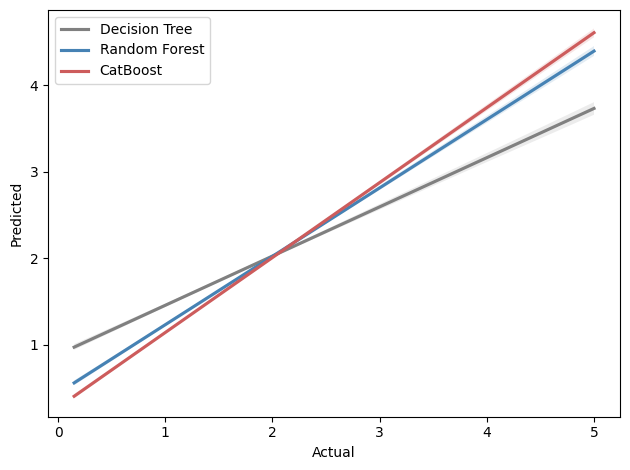

In [16]:
sns.regplot(x=y_test, y=y_pred_dt, scatter=False, label='Decision Tree', color='gray')
sns.regplot(x=y_test, y=y_pred_rf, scatter=False, label='Random Forest', color='steelblue')
sns.regplot(x=y_test, y=y_pred,    scatter=False, label='CatBoost',      color='indianred')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.tight_layout()

---
# Try it with your own data

Pick a dataset you care about — something from a problem set, a project, or a file on your computer. Run the same CatBoost pipeline on it.

**Checklist:**
1. Load it into a `pandas.DataFrame`
2. Know which column is the **target**
3. Decide: is this **classification** (discrete target) or **regression** (continuous)?
4. Identify any **categorical** features

Below is a template using the seaborn `tips` dataset — swap it for your own.

In [ ]:
# -------- REPLACE THIS BLOCK --------
byod = sns.load_dataset('tips')
target_col = 'tip'
task = 'regression'      # 'classification' or 'regression'
# -------- END REPLACE --------

print("Shape:", byod.shape)
byod.head()

In [ ]:
X_byod = byod.drop(columns=[target_col])
y_byod = byod[target_col]

# Auto-detect categorical columns
cat_features_byod = X_byod.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical features:", cat_features_byod)

# Fill NaN in categorical columns with a placeholder
for c in cat_features_byod:
    X_byod[c] = X_byod[c].astype(str).fillna('MISSING')

X_tr, X_te, y_tr, y_te = train_test_split(X_byod, y_byod, test_size=0.2, random_state=42)

In [ ]:
# Pick the right CatBoost class
if task == 'classification':
    Model = CatBoostClassifier
elif task == 'regression':
    Model = CatBoostRegressor

model_byod = Model(iterations=1000, learning_rate=0.05, depth=6, verbose=200)
model_byod.fit(X_tr, y_tr, cat_features=cat_features_byod)

y_pred_byod = model_byod.predict(X_te)

if task == 'classification':
    print(f"Accuracy: {accuracy_score(y_te, y_pred_byod):.4f}")
else:
    print(f"MSE: {mean_squared_error(y_te, y_pred_byod):.4f}")
    print(f"Pearson r: {np.corrcoef(y_te, y_pred_byod)[0, 1]:.4f}")